# 6 — ControlNet: valutazione quantitativa

La generazione condizionata non si valuta col FID (che misura il realismo) ma con il
**DSC**: quanto il volume generato rispetta la maschera che gli e' stata imposta.

Protocollo, per ogni volume:
1. la maschera reale viene data come **condizione** alla ControlNet, che genera da rumore;
2. il volume generato viene **ri-segmentato** con FSL-FAST;
3. si calcola il **Dice** tra la maschera richiesta e quella ottenuta.

Il checkpoint e' scelto per DSC sul **validation**; il **test** e' usato una volta sola,
col checkpoint gia' scelto, per il numero finale.

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt

METRICS="../outputs/metrics"

def load_dsc(tag):
    with open(f"{METRICS}/dsc_{tag}.json") as f:
        return json.load(f)

val={e:load_dsc(f"val_epoch{e}") for e in (60,80,100)}
test=load_dsc("test_epoch100")
tetto=load_dsc("tetto_clean")

print(f"validation: {[ (e, round(d['mean_dsc'],4)) for e,d in val.items() ]}")
print(f"test:       {round(test['mean_dsc'],4)}  (n={test['n_pairs']})")
print(f"tetto:      {round(tetto['mean_dsc'],4)}  (n={tetto['n_pairs']})")

validation: [(60, 0.6523), (80, 0.6747), (100, 0.6774)]
test:       0.6776  (n=102)
tetto:      0.7875  (n=10)


## Il tetto della misura

Prima di leggere qualunque DSC serve sapere **qual e' il massimo ottenibile**. Le due
maschere confrontate non nascono allo stesso modo: quella di condizionamento viene da FAST
sul volume **raw**, quella del generato da FAST su un volume **decodificato dal VAE**, che
ha perso dettaglio attraverso il collo di bottiglia `4 x 64^3`.

Per quantificare questo scarto si prendono volumi **reali**, li si decodifica e ri-segmenta
lungo lo stesso percorso dei sintetici, e si confronta il risultato con la loro maschera di
condizionamento. Essendo lo stesso cervello, un DSC inferiore a 1 misura solo la perdita
introdotta dalla pipeline: e' il **tetto**, non superabile da nessun modello generativo.

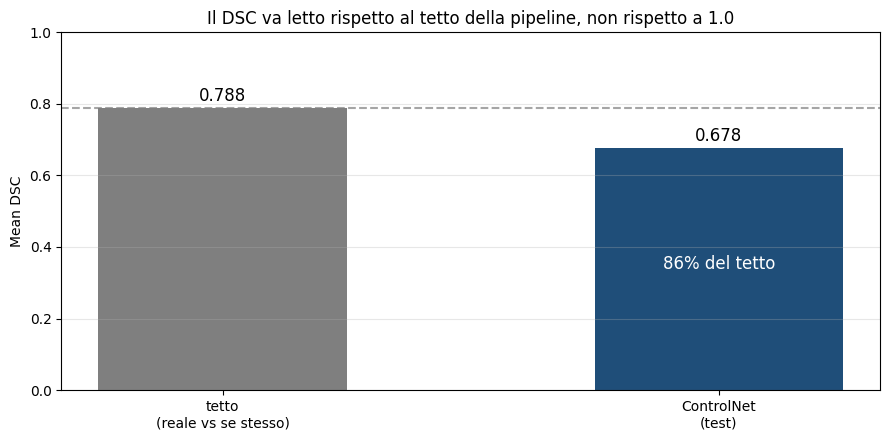

la ControlNet raggiunge il 86.0% del massimo ottenibile con questa pipeline


In [2]:
fig, ax=plt.subplots(figsize=(9,4.5))
labels=["tetto\n(reale vs se stesso)", "ControlNet\n(test)"]
vals=[tetto["mean_dsc"], test["mean_dsc"]]
bars=ax.bar(labels, vals, color=["#7f7f7f","#1f4e79"], width=0.5)
ax.axhline(tetto["mean_dsc"], ls="--", color="#7f7f7f", alpha=0.7)
ax.set_ylim(0,1.0); ax.set_ylabel("Mean DSC")
ax.set_title("Il DSC va letto rispetto al tetto della pipeline, non rispetto a 1.0")
for b,v in zip(bars,vals):
    ax.text(b.get_x()+b.get_width()/2, v+0.02, f"{v:.3f}", ha="center", fontsize=12)
pct=100*test["mean_dsc"]/tetto["mean_dsc"]
ax.text(1, test["mean_dsc"]/2, f"{pct:.0f}% del tetto", ha="center", color="white", fontsize=12)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

print(f"la ControlNet raggiunge il {pct:.1f}% del massimo ottenibile con questa pipeline")

## Selezione del checkpoint (validation)

Tre checkpoint candidati, valutati per DSC sulle 100 maschere di validation. Il test non
viene toccato in questa fase.

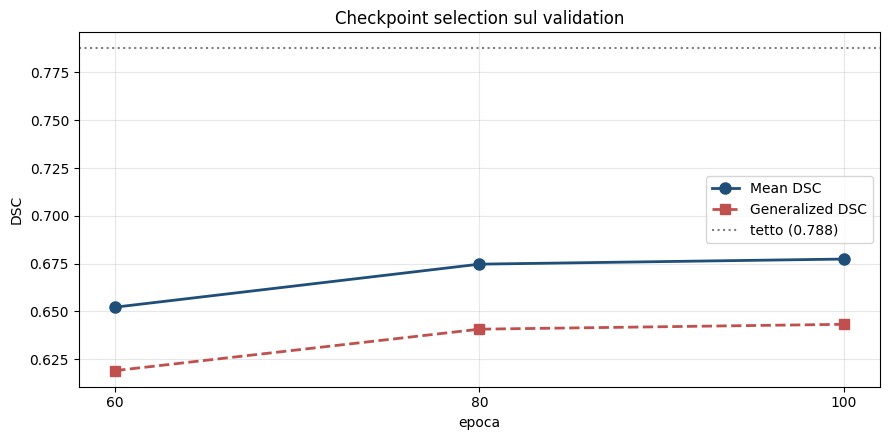

epoca   mean DSC    gen DSC     std     
60      0.6523      0.6191      0.0229  
80      0.6747      0.6408      0.0228  
100     0.6774      0.6433      0.0227  

selezionato: epoch100


In [3]:
epochs=[60,80,100]
means=[val[e]["mean_dsc"] for e in epochs]
gens=[val[e]["generalized_dsc"] for e in epochs]

fig, ax=plt.subplots(figsize=(9,4.5))
ax.plot(epochs, means, "o-", label="Mean DSC", color="#1f4e79", lw=2, ms=8)
ax.plot(epochs, gens, "s--", label="Generalized DSC", color="#c0504d", lw=2, ms=7)
ax.axhline(tetto["mean_dsc"], ls=":", color="#7f7f7f", label=f"tetto ({tetto['mean_dsc']:.3f})")
ax.set_xlabel("epoca"); ax.set_ylabel("DSC"); ax.set_xticks(epochs)
ax.set_title("Checkpoint selection sul validation")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"{'epoca':<8}{'mean DSC':<12}{'gen DSC':<12}{'std':<8}")
for e in epochs:
    d=val[e]
    print(f"{e:<8}{d['mean_dsc']:<12.4f}{d['generalized_dsc']:<12.4f}{d['per_volume_std']:<8.4f}")
print("\nselezionato: epoch100")

## Risultato finale sul test

Il checkpoint scelto viene applicato una volta sola alle 102 maschere di test.

In [4]:
rows=[
    ("validation (selezione)", val[100]),
    ("test (hold-out, finale)", test),
    ("tetto della misura", tetto),
]
print(f"{'split':<26}{'n':>5}{'mean DSC':>11}{'gen DSC':>10}{'std':>8}{'% tetto':>10}")
print("-"*70)
for name,d in rows:
    pct=100*d["mean_dsc"]/tetto["mean_dsc"]
    print(f"{name:<26}{d['n_pairs']:>5}{d['mean_dsc']:>11.4f}{d['generalized_dsc']:>10.4f}"
          f"{d['per_volume_std']:>8.4f}{pct:>9.0f}%")

delta=abs(val[100]["mean_dsc"]-test["mean_dsc"])
print(f"\nscarto validation-test: {delta:.4f}  -> nessun overfitting sulla selezione")

split                         n   mean DSC   gen DSC     std   % tetto
----------------------------------------------------------------------
validation (selezione)      100     0.6774    0.6433  0.0227       86%
test (hold-out, finale)     102     0.6776    0.6407  0.0254       86%
tetto della misura           10     0.7875    0.7473  0.0201      100%

scarto validation-test: 0.0002  -> nessun overfitting sulla selezione


**Validation e test coincidono a 0.0002.** E' la verifica che la selezione del checkpoint
non ha sovradattato il validation: il modello si comporta su volumi mai visti esattamente
come sul set usato per sceglierlo.

## Distribuzione per volume

La media non basta: interessa sapere se il risultato e' uniforme o se dipende da pochi casi
fortunati. Una distribuzione stretta indica un condizionamento affidabile su tutti i soggetti.

/tmp/ipykernel_1192326/1412326376.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([ [v for v in val[e]["per_volume"].values()] for e in epochs ]


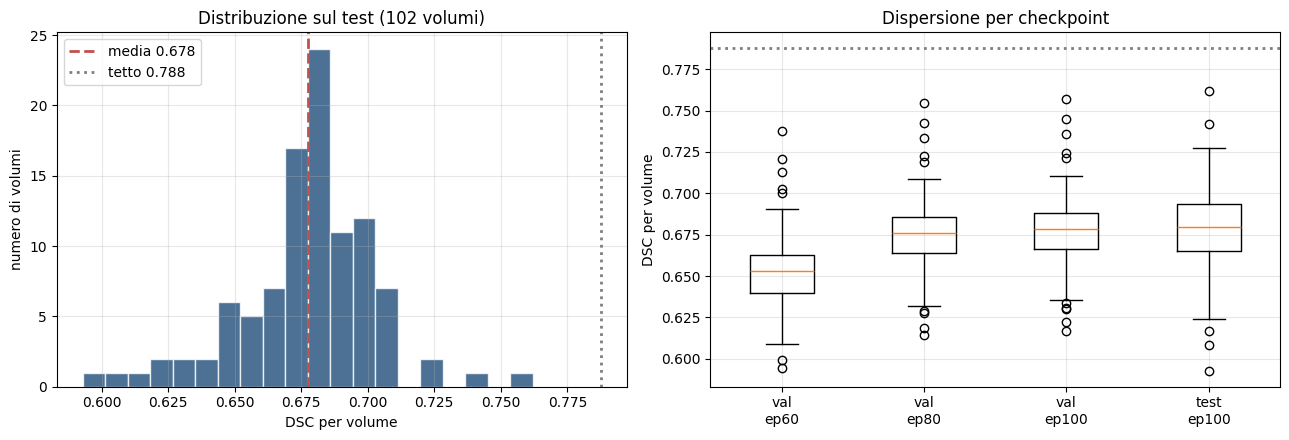

min 0.5929 | max 0.7620 | std 0.0254
nessun caso degenere: il valore piu' basso resta sopra 0.59


In [5]:
scores=np.array(list(test["per_volume"].values()))

fig, axes=plt.subplots(1, 2, figsize=(13,4.5))
axes[0].hist(scores, bins=20, color="#1f4e79", alpha=0.8, edgecolor="white")
axes[0].axvline(scores.mean(), color="#c0504d", ls="--", lw=2, label=f"media {scores.mean():.3f}")
axes[0].axvline(tetto["mean_dsc"], color="#7f7f7f", ls=":", lw=2, label=f"tetto {tetto['mean_dsc']:.3f}")
axes[0].set_xlabel("DSC per volume"); axes[0].set_ylabel("numero di volumi")
axes[0].set_title("Distribuzione sul test (102 volumi)"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].boxplot([ [v for v in val[e]["per_volume"].values()] for e in epochs ]
                + [scores], labels=[f"val\nep{e}" for e in epochs]+["test\nep100"])
axes[1].axhline(tetto["mean_dsc"], color="#7f7f7f", ls=":", lw=2)
axes[1].set_ylabel("DSC per volume"); axes[1].set_title("Dispersione per checkpoint")
axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"min {scores.min():.4f} | max {scores.max():.4f} | std {scores.std():.4f}")
print("nessun caso degenere: il valore piu' basso resta sopra 0.59")

## Caso migliore e caso peggiore

Confronto visivo tra il volume col DSC piu' alto e quello col DSC piu' basso: mostra
concretamente cosa distingue un condizionamento riuscito da uno meno preciso.

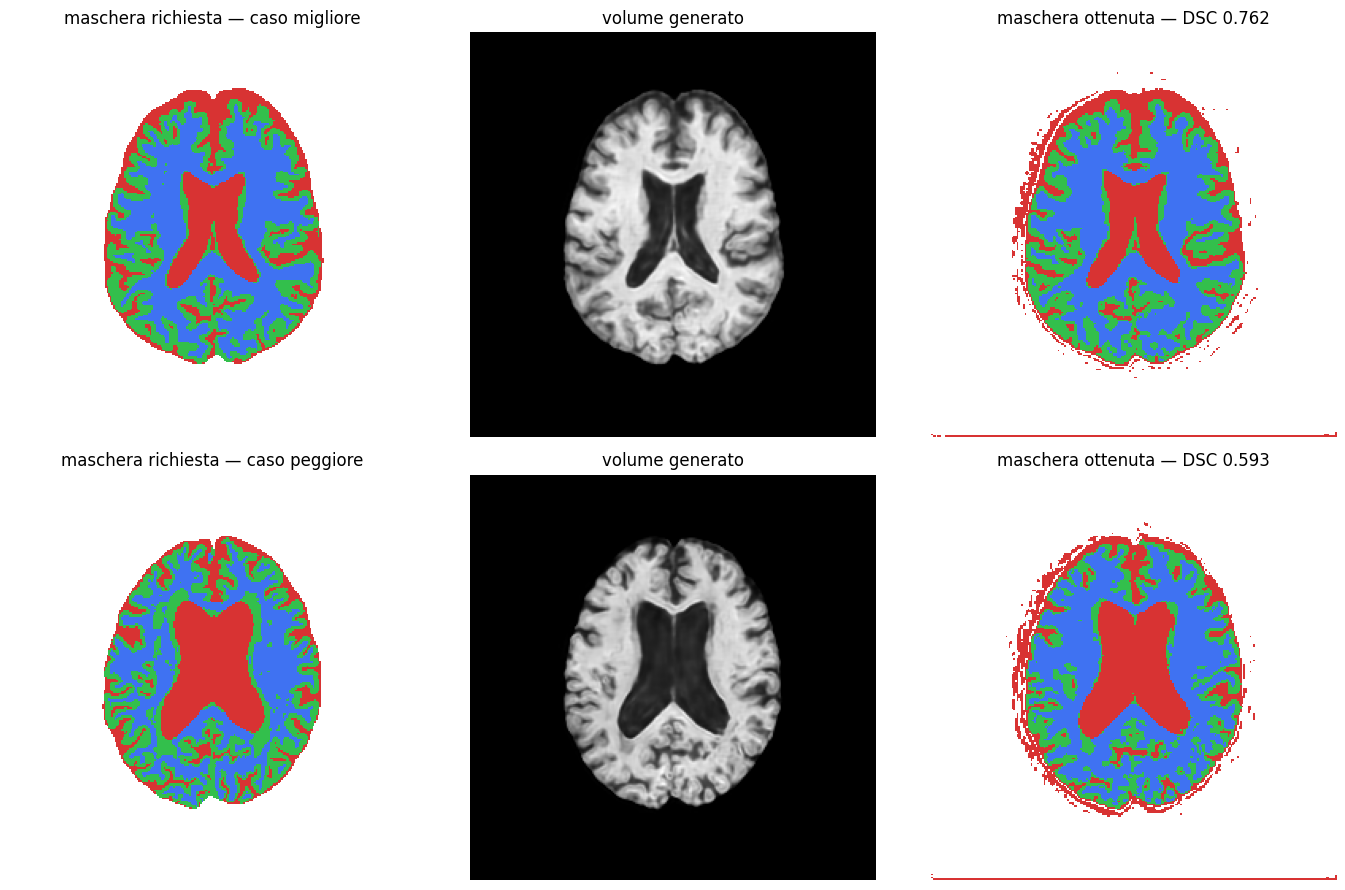

migliore: 0.7620
peggiore: 0.5929


In [6]:
import nibabel as nib
from matplotlib.colors import ListedColormap

GEN_DIR="../data/controlnet_gen_test/epoch100"
TISSUE_CMAP=ListedColormap([(0,0,0,0),(0.85,0.20,0.20,1),(0.20,0.75,0.30,1),(0.25,0.45,0.95,1)])

pv=test["per_volume"]
best=max(pv, key=pv.get); worst=min(pv, key=pv.get)

def load(p): return np.asarray(nib.load(p).dataobj).astype(np.float32)

fig, axes=plt.subplots(2, 3, figsize=(14,9))
for r,(base,tag) in enumerate([(best,"migliore"),(worst,"peggiore")]):
    cond=np.rot90(load(f"{GEN_DIR}/{base}_condmask.nii.gz")[:,:,128])
    seg=np.rot90(load(f"{GEN_DIR}/{base}_synth_pveseg.nii.gz")[:,:,128])
    synth=np.rot90(load(f"{GEN_DIR}/{base}_synth.nii.gz")[:,:,128])
    axes[r,0].imshow(cond, cmap=TISSUE_CMAP, vmin=0, vmax=3, interpolation="nearest")
    axes[r,0].set_title(f"maschera richiesta — caso {tag}")
    axes[r,1].imshow(synth, cmap="gray"); axes[r,1].set_title("volume generato")
    axes[r,2].imshow(seg, cmap=TISSUE_CMAP, vmin=0, vmax=3, interpolation="nearest")
    axes[r,2].set_title(f"maschera ottenuta — DSC {pv[base]:.3f}")
for a in axes.ravel(): a.axis("off")
plt.tight_layout(); plt.show()

print(f"migliore: {pv[best]:.4f}\npeggiore: {pv[worst]:.4f}")

## Lettura dei risultati

**DSC finale sul test: 0.678** (generalizzato 0.641), su 102 volumi hold-out, con deviazione
standard 0.025 e nessun caso degenere.

**Rispetto al tetto della pipeline (0.788), la ControlNet raggiunge l'86% del massimo
ottenibile.** Il 21% che separa il tetto dall'unita' non dipende dal condizionamento ma
dalla struttura della valutazione: la compressione del VAE e il confronto fra maschere
prodotte lungo due percorsi diversi.

**Confrontabilita' con la letteratura.** I valori assoluti non sono direttamente confrontabili
con lavori costruiti su VAE di foundation model preaddestrati: quelli hanno una fedelta' di
ricostruzione superiore e quindi un tetto piu' alto. Qui la base e' un LDM addestrato da zero
su 805 volumi, e la ControlNet dimostra che il controllo spaziale e' realizzabile anche su un
backbone in-house in regime data-scarse.

**Validation e test allineati** (0.6774 e 0.6776) confermano che il protocollo di selezione
del checkpoint ha preservato l'hold-out.